<a href="https://colab.research.google.com/github/brianphu2310/COFFEE-EXTRACTION/blob/main/Brian_Coffee_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  ☕  COFFEE DATA ANALYSIS

📁 Upload your Coffee_Data.xlsx file:


Saving Coffee_Brewing_Methods Dataset.xlsx to Coffee_Brewing_Methods Dataset.xlsx

✅ Loaded: Coffee_Brewing_Methods Dataset.xlsx  (23 rows × 11 cols)
                               ☕  COFFEE BREWING METHODS — COMPLETE GUIDE       Unnamed: 1     Unnamed: 2              Unnamed: 3      Unnamed: 4         Unnamed: 5   Unnamed: 6  Unnamed: 7             Unnamed: 8                                                      Unnamed: 9             Unnamed: 10
0  13 methods ranked by brew time · Data for educational & analytical use              NaN            NaN                     NaN             NaN                NaN          NaN         NaN                    NaN                                                             NaN                     NaN
1                                                                  Method  Brew Time (min)  Caffeine (mg)  Antioxidant Rank (1-5)  Acidity (1-10)  Bitterness (1-10)  Body (1-10)  Complexity  Recommended Equipment                                    

KeyError: 'Cafeine_mg_per_cup'

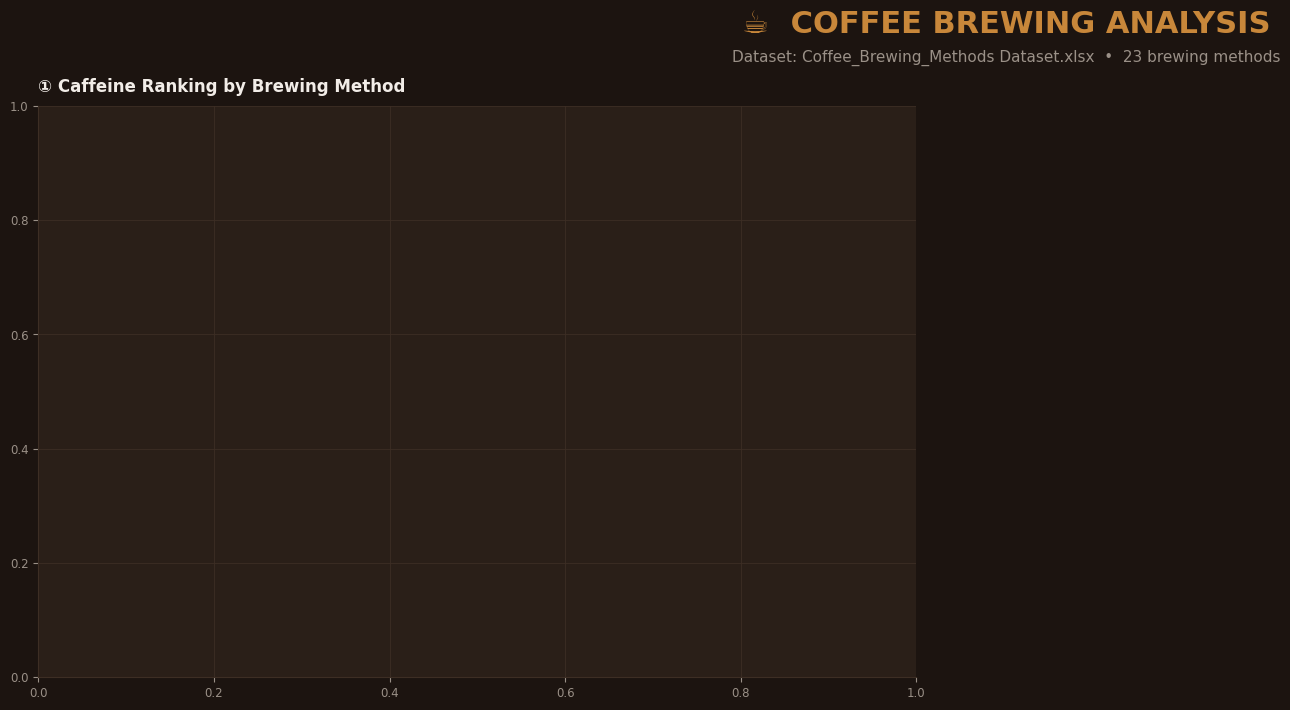

In [1]:
# ============================================================
# ☕ COFFEE DATA ANALYSIS — ALL CHARTS IN ONE BLOCK
# ============================================================

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import io
from google.colab import files

# ── Style ────────────────────────────────────────────────────
BG       = "#1C1410"
PANEL    = "#2A1F18"
ACCENT1  = "#C8873A"   # warm amber
ACCENT2  = "#7FB3A0"   # sage green
ACCENT3  = "#D4735E"   # terracotta
ACCENT4  = "#A89BC2"   # lavender
WHITE    = "#F2EDE8"
SILVER   = "#9A9087"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    "#3D2E24",
    "axes.labelcolor":   WHITE,
    "xtick.color":       SILVER,
    "ytick.color":       SILVER,
    "grid.color":        "#3D2E24",
    "grid.linewidth":    0.6,
    "axes.grid":         True,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "text.color":        WHITE,
    "font.family":       "DejaVu Sans",
})

# ── Upload ───────────────────────────────────────────────────
print("="*52)
print("  ☕  COFFEE DATA ANALYSIS")
print("="*52)
print("\n📁 Upload your Coffee_Data.xlsx file:")

uploaded  = files.upload()
file_name = list(uploaded.keys())[0]
df        = pd.read_excel(io.BytesIO(uploaded[file_name]))

print(f"\n✅ Loaded: {file_name}  ({df.shape[0]} rows × {df.shape[1]} cols)")
print(df.head(3).to_string())

# ── Build master figure  (2 × 2 grid) ───────────────────────
fig = plt.figure(figsize=(22, 16), facecolor=BG)

# Header band
fig.text(0.5, 0.97, "☕  COFFEE BREWING ANALYSIS",
         ha="center", va="top", fontsize=22, fontweight="bold",
         color=ACCENT1)
fig.text(0.5, 0.945, f"Dataset: {file_name}  •  {df.shape[0]} brewing methods",
         ha="center", va="top", fontsize=11, color=SILVER)

gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.38, wspace=0.28,
                       left=0.06, right=0.97,
                       top=0.91, bottom=0.06)

# ── helper ───────────────────────────────────────────────────
def style(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=WHITE, fontsize=12,
                 fontweight="bold", pad=10, loc="left")
    ax.tick_params(colors=SILVER, labelsize=8.5)
    ax.spines["bottom"].set_color("#3D2E24")
    ax.spines["left"].set_color("#3D2E24")


# ════════════════════════════════════════════════════════════
# CHART 1 — Caffeine Ranking
# ════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, 0])
style(ax1, "① Caffeine Ranking by Brewing Method")

df1   = df.sort_values("Cafeine_mg_per_cup", ascending=True)
colors = [ACCENT1 if v == df1["Cafeine_mg_per_cup"].max() else ACCENT3
          for v in df1["Cafeine_mg_per_cup"]]
bars  = ax1.barh(df1["Method"], df1["Cafeine_mg_per_cup"],
                 color=colors, alpha=0.88, edgecolor=BG, linewidth=0.5)
ax1.set_xlabel("Caffeine (mg)", color=SILVER, fontsize=9)
ax1.set_xlim(0, df1["Cafeine_mg_per_cup"].max() * 1.18)
for bar, val in zip(bars, df1["Cafeine_mg_per_cup"]):
    ax1.text(bar.get_width() + 6, bar.get_y() + bar.get_height() / 2,
             f"{val:.0f} mg", va="center", fontsize=8, color=WHITE)


# ════════════════════════════════════════════════════════════
# CHART 2 — Brew Time vs Caffeine (log scale)
# ════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[0, 1])
style(ax2, "② Brew Time vs Caffeine")

sc = ax2.scatter(df["Time_Minutes"], df["Cafeine_mg_per_cup"],
                 s=110, alpha=0.85, c=ACCENT2,
                 edgecolors=WHITE, linewidths=0.5, zorder=3)
for _, row in df.iterrows():
    ax2.annotate(row["Method"],
                 (row["Time_Minutes"], row["Cafeine_mg_per_cup"]),
                 xytext=(6, 4), textcoords="offset points",
                 fontsize=7.5, color=WHITE, alpha=0.88)
ax2.set_xscale("log")
ax2.set_xlabel("Brew Time (minutes — log scale)", color=SILVER, fontsize=9)
ax2.set_ylabel("Caffeine (mg)", color=SILVER, fontsize=9)


# ════════════════════════════════════════════════════════════
# CHART 3 — Correlation Heatmap
# ════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, 0])
style(ax3, "③ Correlation Matrix")

corr_cols = ["Time_Minutes", "Cafeine_mg_per_cup",
             "Antioxidant_rank", "Acidity (1-10)",
             "Bitterness (1-10)", "Body (1-10)"]
corr  = df[corr_cols].corr()
cmap  = sns.diverging_palette(20, 160, as_cmap=True)
sns.heatmap(corr, annot=True, cmap=cmap, center=0,
            fmt=".2f", square=True, ax=ax3,
            linewidths=0.5, linecolor=BG,
            annot_kws={"size": 8, "color": WHITE},
            cbar_kws={"shrink": 0.75})
ax3.tick_params(colors=WHITE, labelsize=8)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=30,
                    ha="right", color=WHITE)
ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0, color=WHITE)


# ════════════════════════════════════════════════════════════
# CHART 4 — Taste Profile (grouped bars)
# ════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[1, 1])
style(ax4, "④ Taste Profile Comparison")

methods = df["Method"].tolist()
x       = np.arange(len(methods))
w       = 0.28

b1 = ax4.bar(x - w, df["Acidity (1-10)"],   width=w, label="Acidity",
             color=ACCENT2,  alpha=0.88, edgecolor=BG, linewidth=0.4)
b2 = ax4.bar(x,     df["Bitterness (1-10)"], width=w, label="Bitterness",
             color=ACCENT3,  alpha=0.88, edgecolor=BG, linewidth=0.4)
b3 = ax4.bar(x + w, df["Body (1-10)"],       width=w, label="Body",
             color=ACCENT4,  alpha=0.88, edgecolor=BG, linewidth=0.4)

ax4.set_xticks(x)
ax4.set_xticklabels(methods, rotation=35, ha="right", fontsize=8, color=WHITE)
ax4.set_ylabel("Score (1–10)", color=SILVER, fontsize=9)
ax4.set_ylim(0, 11)
ax4.legend(fontsize=9, framealpha=0.15, labelcolor=WHITE,
           loc="upper left", ncol=3)


# ── Footer ───────────────────────────────────────────────────
fig.text(0.5, 0.01,
         "Highest Caffeine: Cold Brew & Moka Pot  •  "
         "Best Antioxidant: AeroPress  •  "
         "Most Acidic: Pour Over  •  Fullest Body: Ristretto / Espresso",
         ha="center", fontsize=9, color=SILVER)

# ── Save & show ──────────────────────────────────────────────
plt.savefig("coffee_analysis_dashboard.png", dpi=180,
            bbox_inches="tight", facecolor=BG)
plt.show()

print("\n✅  Dashboard saved → coffee_analysis_dashboard.png")
print("="*52)
print("  KEY INSIGHTS")
print("="*52)
print(f"  Highest caffeine : {df.loc[df['Cafeine_mg_per_cup'].idxmax(), 'Method']}  "
      f"({df['Cafeine_mg_per_cup'].max():.0f} mg)")
print(f"  Lowest caffeine  : {df.loc[df['Cafeine_mg_per_cup'].idxmin(), 'Method']}  "
      f"({df['Cafeine_mg_per_cup'].min():.0f} mg)")
print(f"  Most acidic      : {df.loc[df['Acidity (1-10)'].idxmax(), 'Method']}")
print(f"  Most bitter      : {df.loc[df['Bitterness (1-10)'].idxmax(), 'Method']}")
print(f"  Fullest body     : {df.loc[df['Body (1-10)'].idxmax(), 'Method']}")
print("="*52)